## Stratified Sampling (Muestreo estratificado)

Es una técnica para dividir tus datos en Train (Entrenamiento) y Test (Prueba) asegurándote de que ambos grupos mantengan las mismas proporciones de la realidad.

En lugar de dejarlo todo a la suerte, el algoritmo divide los datos en "capas" o "estratos" importantes (por ejemplo: rangos de ingresos, géneros o condiciones médicas) y saca una muestra justa de cada capa.

### ⚠️ El gran peligro del Muestreo Aleatorio (Al Azar)
Si dejas la separación puramente al azar, la suerte te puede jugar en contra, especialmente en datasets pequeños o cuando tienes clases muy desbalanceadas (grupos minoritarios pero importantes).

El **muestreo aleatorio simple solo funciona bien si tu conjunto de datos es gigantesco**. Si el dataset es enorme, las probabilidades se estabilizan solas.

Pero si tus **datos son limitados** o buscas predecir algo raro (como fraudes con tarjetas, enfermedades extrañas o ingresos muy altos en California Housing), debes usar **Stratified Sampling** obligatoriamente para no sesgar tu modelo.

## Dataset

En nuestro dataset el ingreso medio del distrito va a ser muy importante para predecir el precio medio de las casas. Aquí hay una correlación.

## ¿Qué es un contrafactual?

La idea de desarrollar proyectos de machine learning es apoyarnos en tomar mejores decisiones.

- En el análisis causal, un contrafactual es el escenario imaginario de lo que habría ocurrido si hubieras tomado una decisión diferente. Es como viajar a un universo paralelo. (Te preguntas que hubiera pasado si hubiera hecho esto)

Ejemplo:

- Te dolía la cabeza, te tomaste una aspirina y a los 20 minutos se te quitó el dolor. Tú dices: "La aspirina me curó".
- El contrafactual sería: ¿Qué le habría pasado a tu cabeza en ese mismo instante si no te hubieras tomado la aspirina? ¿Se te habría quitado el dolor de todos modos por haber descansado?

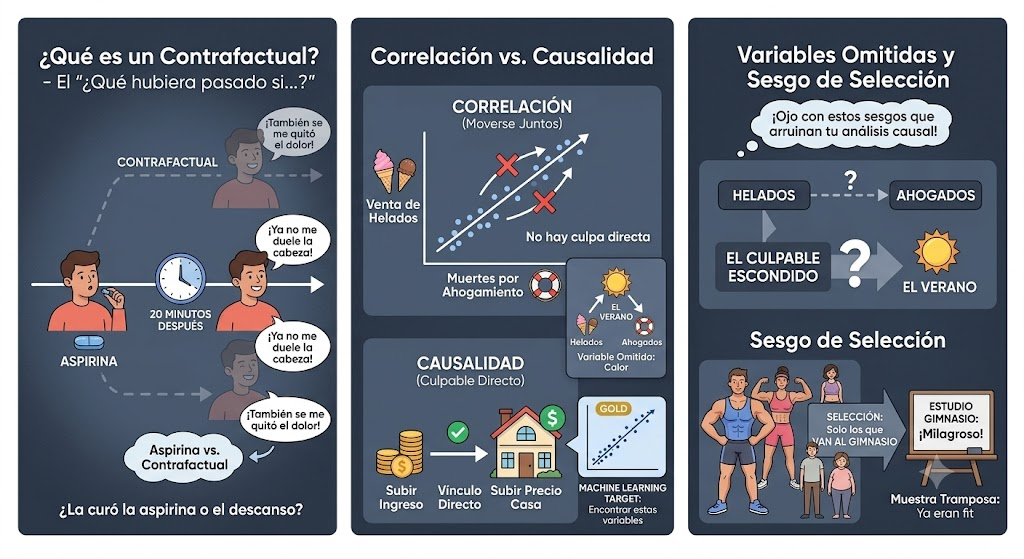

## Correlación vs Causalidad

- la correlación es que dos cosas cambien al mismo tiempo.
- La causalidad exige que una sea la culpable directa de la otra. Puede ser verdad o no. Se debe analizar.

Ejemplo:
- Cuando aumenta la venta de helados en una ciudad, también aumentan las muertes por ahogamiento en las piscinas
- ¿Los helados causan que la gente se ahogue? No. Eso sería causalidad falsa.
- Lo que pasa es que hay una tercera variable oculta: El verano. El calor hace que la gente compre helados Y TAMBIÉN hace que la gente se meta a la piscina.

- En el dataset el ingreso medio del distrito esté correlacionado con casas caras es obvio. Pero, ¿qué causa el precio alto? ¿El dinero de la gente, o que el distrito está frente al mar y por eso la gente rica quiere vivir ahí?

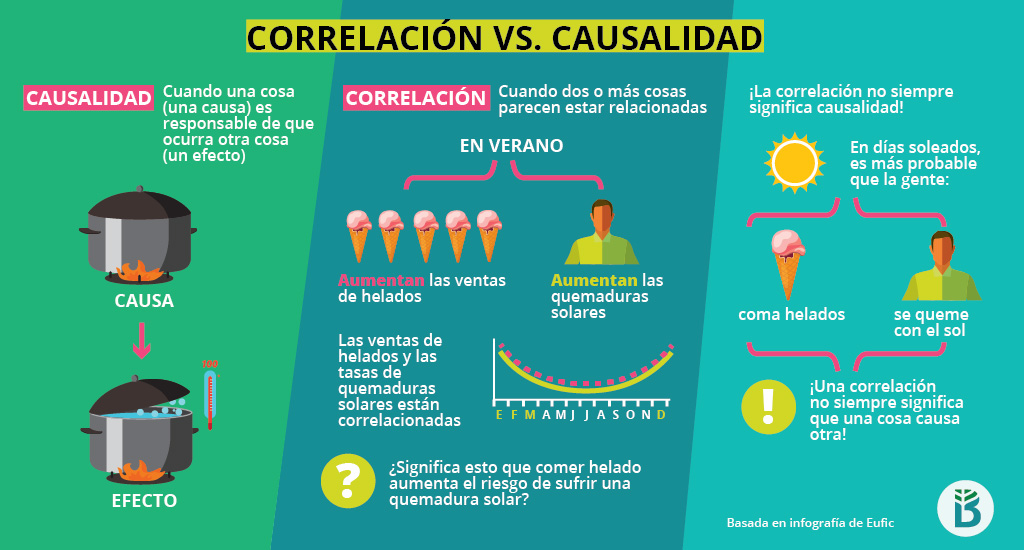

## Variables omitidas y sesgos de selección

Estos son los dos errores más comunes que arruinan un análisis si solo usas Machine Learning básico:

- Variables Omitidas (El culpable escondido): Es cuando olvidas meter un dato importante en tu modelo. En el ejemplo anterior, "El verano" es la variable omitida. Si tu modelo solo ve helados y ahogados, culpará a los helados.
- Sesgo de Selección (Muestra tramposa): Ocurre cuando los datos que recolectaste no representan a la gente común.

Ejemplo:
- Quieres medir si un nuevo gimnasio funciona. Haces un estudio con 100 personas que van al gimnasio y ves que están súper en forma. Dices: "El gimnasio es milagroso". El sesgo de selección es que la gente que decide ir al gimnasio ya es de por sí gente que se cuida y hace dieta. El resultado ya estaba "trucado" desde el inicio.

## Ciencia de datos causal

- La Ciencia de Datos tradicional (el Machine Learning normal) se enfoca en predecir: "Si veo una casa en este distrito con este ingreso, predigo que costará $500,000".
- La Causal Data Science va un paso más allá y se enfoca en optimizar acciones. No solo predice el futuro, sino que te dice qué botón apretar para cambiarlo. Usa gráficos de flechas (llamados DAGs) y fórmulas especiales para aislar las variables omitidas y los sesgos que vimos arriba, permitiendo calcular el impacto real de una decisión.

## Casos

Las empresas grandes no usan Machine Learning solo para adivinar el precio de las casas, lo usan para tomar decisiones causales: Te da otra prespectiva de ver el negocio.

- Netflix o Spotify (Recomendaciones): Si te recomiendan una película y la ves, ¿la viste porque te la recomendaron, o porque ya tenías ganas de verla y la habrías buscado tú mismo (contrafactual)? Medir esto les ayuda a saber si su algoritmo de recomendación realmente sirve.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import polars as pl

In [5]:
PATH_CALIFORNIA = "/content/drive/MyDrive/machine_learning/california_housing/"
df_california_housing = pd.read_csv(f"{PATH_CALIFORNIA}housing.csv")
pl_california_housing = pl.read_csv(f"{PATH_CALIFORNIA}housing.csv")

df_california_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Creando categorias con pandas
- con ``cut()`` se utiliza para datos númericos continuos y convertilo en intervalos (bins)
- con ``bis`` se va a definir los rangos.  Como de 0 - 1.5, entre otros compara el valor de median_income y le asigna la categoría correspondiente. Los estratos pequeños pueden perjudicar.
- con ``labels`` se relaciona con cada bins, se asigna viendo en el histograma donde esta la mayor cantidad de datos.

In [6]:
df_california_housing["income_cat"] = pd.cut(
    df_california_housing["median_income"],
    bins=[0.,1.5,3.0,4.5,6., np.inf],
    labels=[1,2,3,4,5]
)

In [7]:
df_california_housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


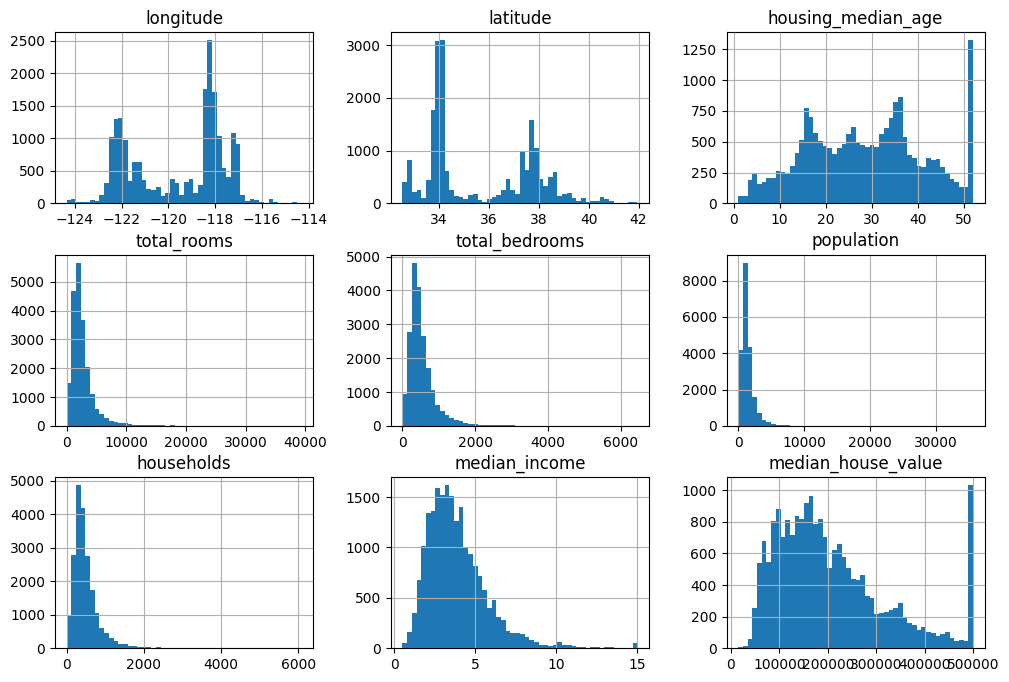

In [8]:
df_california_housing.hist(bins=50, figsize=(12, 8))
plt.show()

Donde mayor cantidad de datos en el median_income se ve que va desde el 0 hasta 5 

In [9]:
pl_california_housing = pl_california_housing.with_columns(
    pl.col("median_income")
    .cut(
        breaks = [1.5, 3.0, 4.5, 6.0],
        labels = ["1", "2", "3", "4", "5"]
    ).alias("income_cat")
)

In [10]:
pl_california_housing.head()

longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
f64,f64,f64,f64,f64,f64,f64,f64,f64,str,cat
-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,"""NEAR BAY""","""5"""
-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,"""NEAR BAY""","""5"""
-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,"""NEAR BAY""","""5"""
-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,"""NEAR BAY""","""4"""
-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,"""NEAR BAY""","""3"""


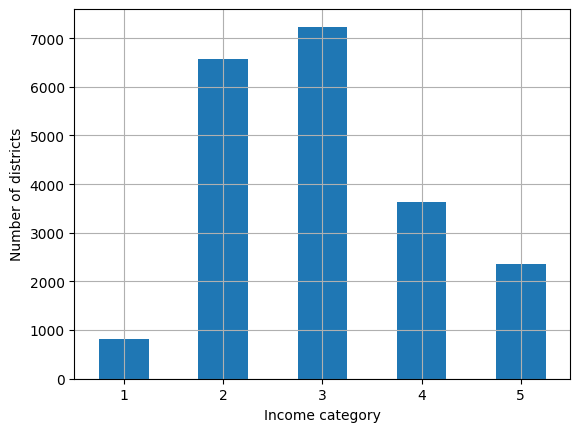

In [11]:
cat_counts = df_california_housing["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

- analizando con muestreo aleatorio solamente tomaria en cuenta las categorias con datos grandes pero no vea ninguna de la categoría 1.
- stratified Sampling defines la categoría de acuerdo a esta variable categorica 1 y se va a aplicar las divisiones.

### Metodo 1: StratifiedShuffleSplit de Scikit Learn

Divide el dataset en train/test múltiples veces, manteniendo la proporción de una variable categoríca.

In [12]:
from sklearn.model_selection import StratifiedShuffleSplit

# 1. Configurar la máquina divisora
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []

# 2. Hacer los cortes manteniendo las proporciones
for train_index, test_index in splitter.split(df_california_housing, df_california_housing["income_cat"]):
    strat_train_set_n = df_california_housing.iloc[train_index]
    strat_test_set_n = df_california_housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

# 3. Extraer el primer par definitivo
strat_train_set, strat_test_set = strat_splits[0]

## Metodo 2: train test split

Solamente me va a retornar 1 elmento de esos

In [13]:
from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    df_california_housing, 
    test_size=0.2, 
    stratify=df_california_housing["income_cat"], 
    random_state=42
)

In [14]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


In [15]:
# 1. Eliminar la columna temporal 'income_cat' de ambos sets
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

## EDA (Análisis Exploratorio de los datos)

Cuando estas en el EDA solamente se utiliza solamene el train set, en esta parte se analiza:
- visualización de los datos.
- detectar relaciones entre variables
- identificar outlier y anomalías
- Generar hiótesis sobre el problema
- Descubrir insights ocultos

In [16]:
# Tener una copia de los datos originales

housing = strat_train_set.copy()

### Exploración y visualización

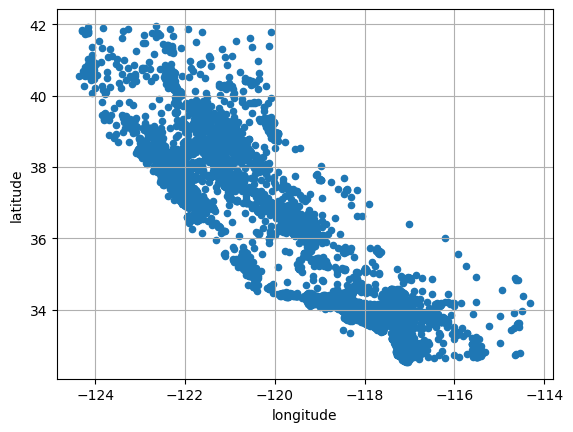

In [17]:
# Graficar los distritos usando latitud y longitud en un diagrama de dispersión (scatter)
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True)

# Mostrar la gráfica en pantalla
plt.show()

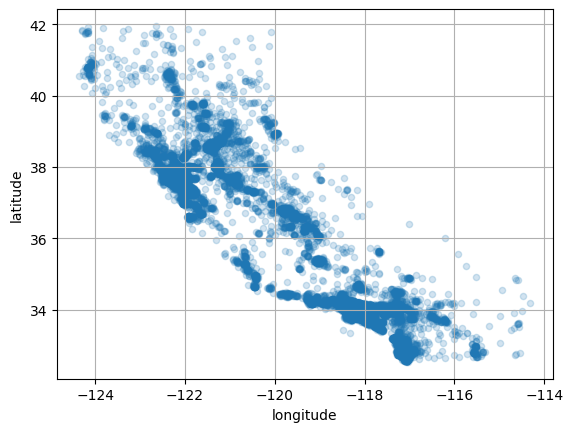

In [18]:
# alpha para controlar la transparencia ya que con 1.0 no se va a poder visualizar correctamente
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)

# Mostrar la gráfica en pantalla
plt.show()

mapa de california los distritos estan cerca al mar

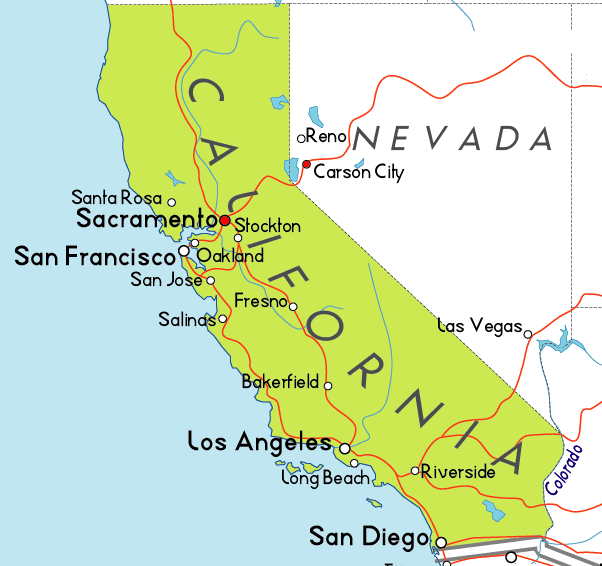

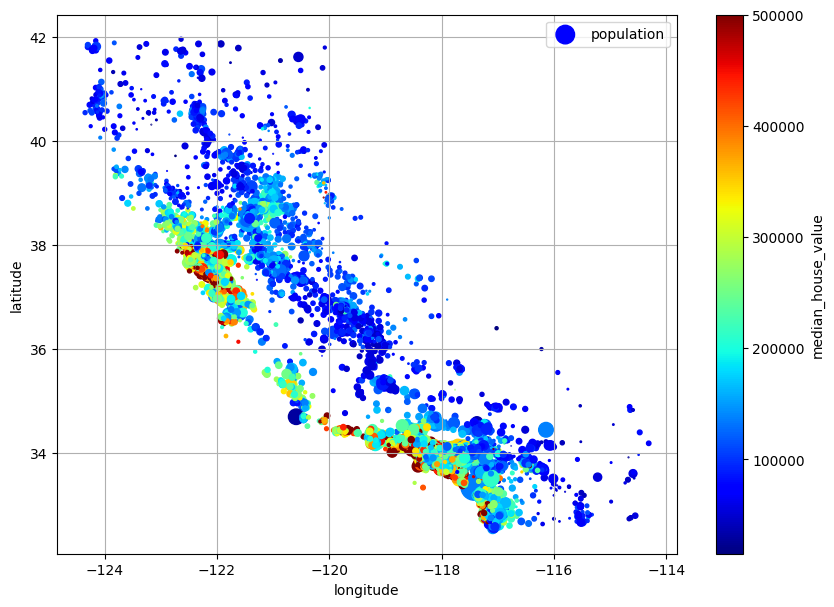

In [19]:
# Usamos la función .plot() para empezar a dibujar nuestro mapa de puntos
housing.plot(
    kind="scatter",           # 1. Le decimos que dibuje un gráfico de dispersión (un mapa de puntitos)
    x="longitude",           # 2. La coordenada Horizontal (Eje X) será la longitud del distrito
    y="latitude",            # 3. La coordenada Vertical (Eje Y) será la latitud del distrito
    grid=True,               # 4. Ponle una cuadrícula gris de fondo para guiar la vista
    
    # --- AQUÍ VIENE LO AVANZADO ---
    
    # 5. El TAMAÑO ('s' de size) del círculo dependerá de la población del distrito.
    # Lo dividimos entre 100 para que los círculos no sean gigantes y no se tapen entre sí.
    s=housing["population"] / 100, 
    
    label="population",      # 6. Ponle una etiqueta en la leyenda que explique que el tamaño es la población
    
    # 7. El COLOR ('c') de cada círculo cambiará según el precio medio de las casas en ese distrito
    c="median_house_value", 
    
    cmap="jet",              # 8. Usa la paleta "jet": Azul = Casas baratas, Rojo = Casas caras (Muy intuitivo)
    colorbar=True,           # 9. Dibuja la barra de colores al lado derecho para saber a cuántos dólares equivale cada color
    legend=True,             # 10. Muestra la leyenda de los tamaños en una esquina del mapa
    sharex=False,            # 11. Evita problemas visuales con los nombres de los ejes si Pandas intenta clonarlos
    figsize=(10, 7)          # 12. Haz que la ventana del mapa sea grande (10 de ancho por 7 de alto) para ver todo bien limpio
)

# ¡La orden final para que Python pinte la gráfica en tu pantalla de inmediato!
plt.show()

Nos dice esta gráfica que los valores de los distritos se encuentran más caras cerca al oceano.

In [20]:
# Correlación entre todas las variables númericas de todas las columnas 
corr_matrix = df_california_housing.corr(numeric_only=True)

In [21]:
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


En esta ocasión encontro una correlación muy fuerte, tiene sentido el valor de la casa depende tambien de la economia de la persona.

Ahora vamos a ver como crear una matriz de gráficos de dispersión. Esto te permite ver de forma visual cómo se correlacionan múltiples variables entre sí al mismo tiempo.

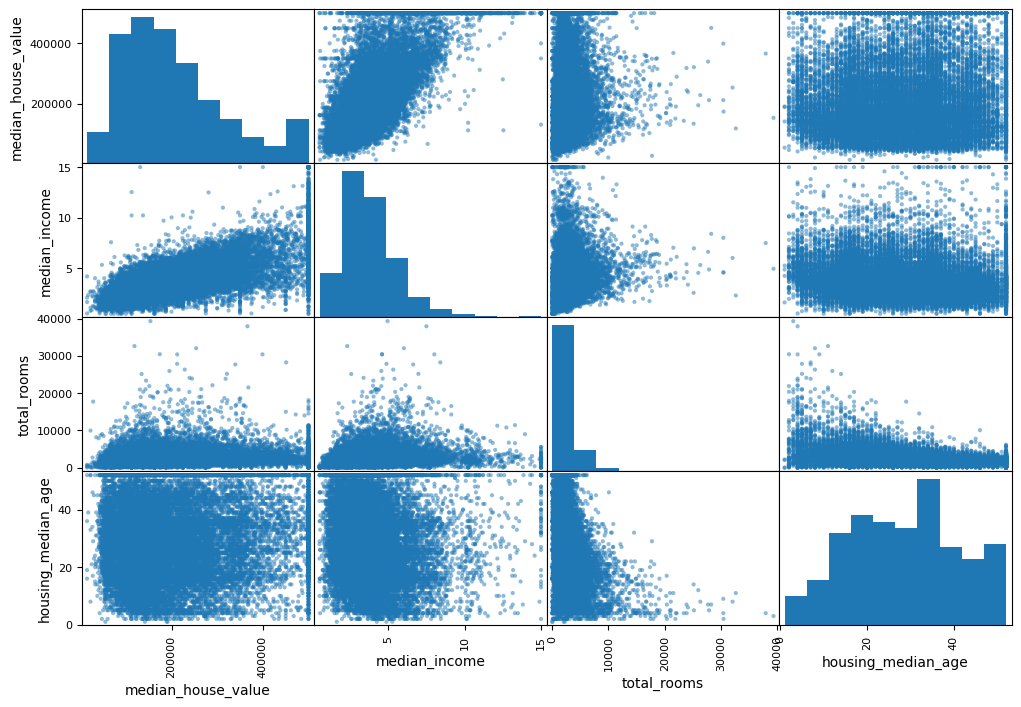

In [22]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", 
              "housing_median_age"]

scatter_matrix(df_california_housing[attributes], figsize=(12, 8))
plt.show()

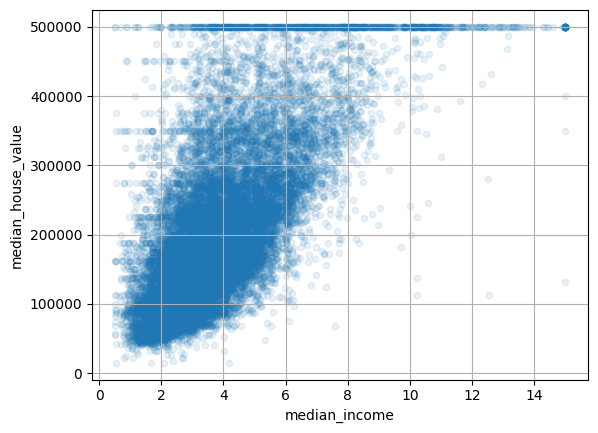

In [25]:
df_california_housing.plot(kind="scatter", x="median_income", y="median_house_value",
                alpha=0.1, grid=True)
plt.show()

Los precios de las viviendas del dataset original fueron "topeados" o truncados artificialmente a un máximo de $500,000. Cualquier casa que costara eso o más, se registró exactamente como $500,000. 

Es un problema grave (outlier masivo o sesgo). Si dejas esos datos así, tu modelo de Machine Learning va a aprender que $500,000 es un límite real del mundo y reproducirá ese comportamiento erróneo (no sabrá predecir casas más caras).

In [29]:
df_california_housing["rooms_per_house"] = df_california_housing["total_rooms"] / df_california_housing["households"]
df_california_housing["bedrooms_ratio"] = df_california_housing["total_bedrooms"] / df_california_housing["total_rooms"]
df_california_housing["people_per_house"] = df_california_housing["population"] / df_california_housing["households"]

In [30]:
corr_matrix = df_california_housing.corr(numeric_only=True)

In [31]:
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688075
rooms_per_house,0.151948
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
people_per_house,-0.023737
population,-0.024650
longitude,-0.045967


A medida que aumenta la cantidad de habitaciones el precio puede disminuir.